<a href="https://colab.research.google.com/github/PihuCodeTech/Aircraft-Engine-RUL-Prediction/blob/main/FeatureSelection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

══════════════════════════════════════════════════════════════════════
  VARIANCE TABLE (std after MinMax normalization)
══════════════════════════════════════════════════════════════════════

  Feature          FD001       FD002       FD003       FD004     Min_std        Status
  ────────────────────────────────────────────────────────────────────
  op1            0.1257      0.3511      0.1275      0.3519       0.1257   ✅ KEEP (op)
  op2            0.2442      0.3682      0.2262      0.3690       0.2262   ✅ KEEP (op)
  op3            0.0000      0.3559      0.0000      0.3563       0.0000   ✅ KEEP (op)
  s1             0.0000      0.3582      0.0000      0.3589       0.0000     ⚠️  MIXED
  s2             0.1506      0.3421      0.1225      0.3428       0.1225        ✅ KEEP
  s3             0.1337      0.2870      0.1333      0.2867       0.1333        ✅ KEEP
  s4             0.1519      0.2867      0.1525      0.2866       0.1519        ✅ KEEP
  s5             0.0000      0.3374     

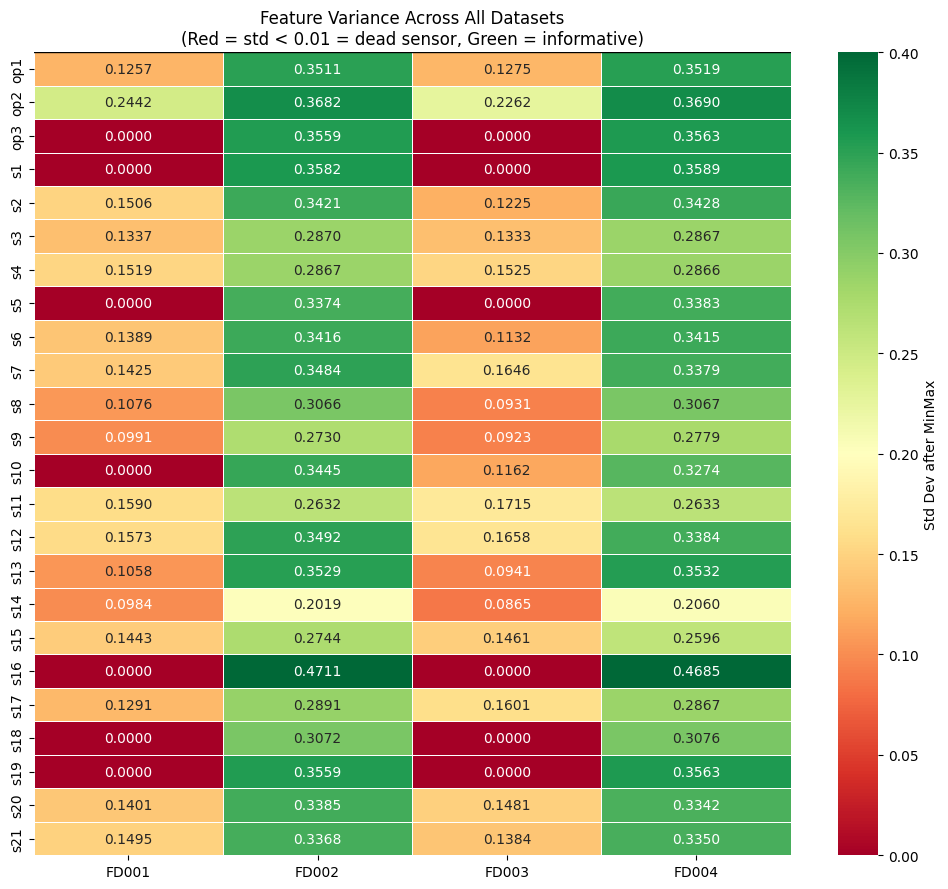

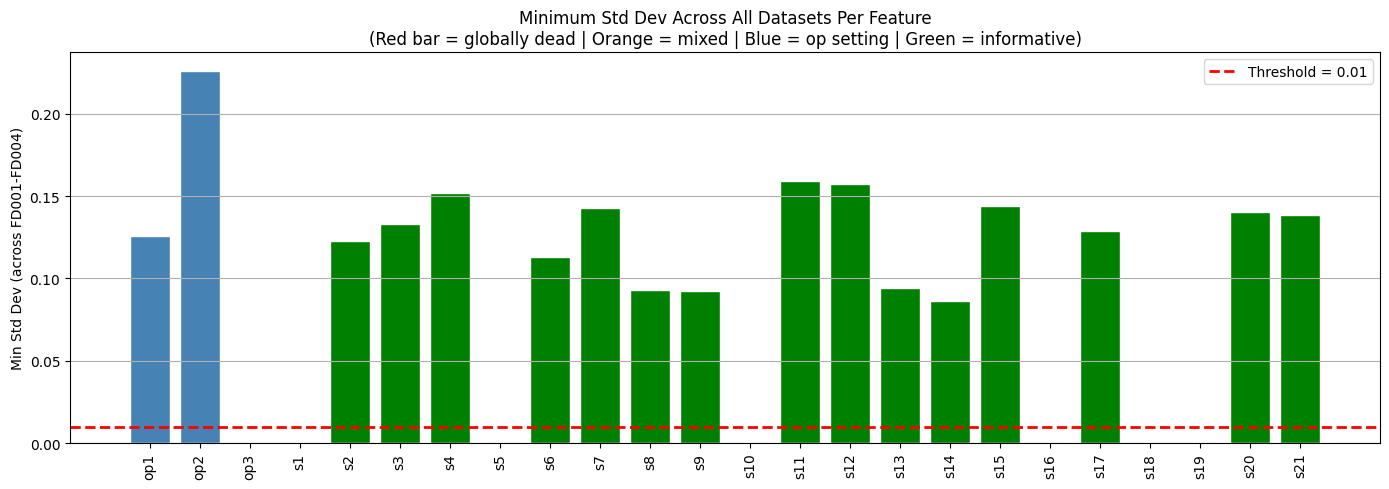

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# VARIANCE-BASED FEATURE SELECTION
# Goal: identify globally dead sensors across all 4 datasets
# Strategy: variance threshold only — no correlation filtering
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

DATA_PATH = '/content/'
cols      = ['id','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)]
DATASETS  = ['FD001','FD002','FD003','FD004']

# All features to analyze (keep op settings always)
sensor_cols = [f's{i}' for i in range(1,22)]
op_cols     = ['op1','op2','op3']
all_feat    = op_cols + sensor_cols   # cycle excluded — not a sensor

VAR_THRESHOLD = 0.01   # after MinMax normalization

# ══════════════════════════════════════════════════════════════════════════════
# Compute variance per feature per dataset
# ══════════════════════════════════════════════════════════════════════════════
variance_table = {}

for ds in DATASETS:
    df = pd.read_csv(f"{DATA_PATH}train_{ds}.txt", sep=r"\s+", header=None)
    df.columns = cols

    # Normalize before computing variance
    scaler = MinMaxScaler()
    df_norm = df.copy()
    df_norm[all_feat] = scaler.fit_transform(df[all_feat])

    stds = df_norm[all_feat].std()
    variance_table[ds] = stds

var_df = pd.DataFrame(variance_table)   # shape: features × datasets

# ══════════════════════════════════════════════════════════════════════════════
# Print variance table
# ══════════════════════════════════════════════════════════════════════════════
print("═"*70)
print("  VARIANCE TABLE (std after MinMax normalization)")
print("═"*70)
print(f"\n  {'Feature':<10}", end='')
for ds in DATASETS:
    print(f"  {ds:>10}", end='')
print(f"  {'Min_std':>10}  {'Status':>12}")
print("  " + "─"*68)

global_keep = []
global_drop = []
inconsistent = []

for feat in all_feat:
    row     = var_df.loc[feat]
    min_std = row.min()
    max_std = row.max()

    # Dead in ALL datasets → global drop
    all_dead = all(row < VAR_THRESHOLD)
    # Alive in ALL datasets → global keep
    all_alive = all(row >= VAR_THRESHOLD)
    # Mixed → inconsistent
    mixed = not all_dead and not all_alive

    if feat in op_cols:
        status = "✅ KEEP (op)"
        global_keep.append(feat)
    elif all_dead:
        status = "❌ DEAD"
        global_drop.append(feat)
    elif all_alive:
        status = "✅ KEEP"
        global_keep.append(feat)
    else:
        status = "⚠️  MIXED"
        inconsistent.append(feat)

    print(f"  {feat:<10}", end='')
    for ds in DATASETS:
        val   = var_df.loc[feat, ds]
        color = "" if val >= VAR_THRESHOLD else " *"
        print(f"  {val:>9.4f}{color[0] if color else ' '}", end='')
    print(f"  {min_std:>10.4f}  {status:>12}")

# ══════════════════════════════════════════════════════════════════════════════
# Summary
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'═'*70}")
print(f"  SUMMARY")
print(f"{'═'*70}")
print(f"\n  Global KEEP  ({len(global_keep)}): {global_keep}")
print(f"  Global DROP  ({len(global_drop)}): {global_drop}")
print(f"  MIXED/CHECK  ({len(inconsistent)}): {inconsistent}")

print(f"""
  Decision rules applied:
    op1, op2, op3  → ALWAYS KEEP (condition identifiers)
    std < {VAR_THRESHOLD} in ALL datasets → GLOBAL DROP (physically dead)
    std < {VAR_THRESHOLD} in SOME datasets → MIXED (review manually)
    std >= {VAR_THRESHOLD} in ALL datasets → GLOBAL KEEP
""")

# ══════════════════════════════════════════════════════════════════════════════
# Heatmap — variance across all datasets
# ══════════════════════════════════════════════════════════════════════════════
plt.figure(figsize=(10, 9))
mask = pd.DataFrame(False, index=var_df.index, columns=var_df.columns)

# Annotate with actual values
sns.heatmap(var_df, annot=True, fmt='.4f', cmap='RdYlGn',
            vmin=0, vmax=0.4,
            linewidths=0.5,
            cbar_kws={'label': 'Std Dev after MinMax'})

# Mark threshold line
plt.axhline(y=0, color='black', linewidth=1)
plt.title(f'Feature Variance Across All Datasets\n'
          f'(Red = std < {VAR_THRESHOLD} = dead sensor, '
          f'Green = informative)')
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Bar chart: min variance across datasets per feature
# ══════════════════════════════════════════════════════════════════════════════
min_std_per_feat = var_df.min(axis=1)
colors = []
for feat in all_feat:
    if feat in op_cols:
        colors.append('steelblue')
    elif feat in global_drop:
        colors.append('red')
    elif feat in inconsistent:
        colors.append('orange')
    else:
        colors.append('green')

plt.figure(figsize=(14, 5))
bars = plt.bar(all_feat, min_std_per_feat, color=colors, edgecolor='white')
plt.axhline(VAR_THRESHOLD, color='red', linestyle='--',
            linewidth=2, label=f'Threshold = {VAR_THRESHOLD}')
plt.xticks(rotation=90)
plt.title('Minimum Std Dev Across All Datasets Per Feature\n'
          '(Red bar = globally dead | Orange = mixed | '
          'Blue = op setting | Green = informative)')
plt.ylabel('Min Std Dev (across FD001-FD004)')
plt.legend()
plt.tight_layout()
plt.grid(axis='y')
plt.show()



In [19]:
print("Calculating RUL for each engine in all training datasets...")

# Dictionary to store RUL dataframes for each dataset
rul_data_per_dataset = {}

for ds in DATASETS:
    # Load training data
    df_train = pd.read_csv(f"{DATA_PATH}train_{ds}.txt", sep=r"\s+", header=None)
    df_train.columns = cols

    # Calculate max cycle for each engine (id)
    max_cycles_per_engine = df_train.groupby('id')['cycle'].max()

    # Merge max_cycles back to the dataframe to calculate RUL
    df_train = df_train.merge(max_cycles_per_engine.rename('max_cycle'),
                              left_on='id',
                              right_index=True,
                              how='left')

    # Calculate RUL: RUL = max_cycle_for_that_engine - current_cycle
    df_train['RUL'] = df_train['max_cycle'] - df_train['cycle']
    rul_data_per_dataset[ds] = df_train[['id', 'cycle', 'RUL']]

print("RUL calculation complete.")

Calculating RUL for each engine in all training datasets...
RUL calculation complete.


Generating RUL plots...


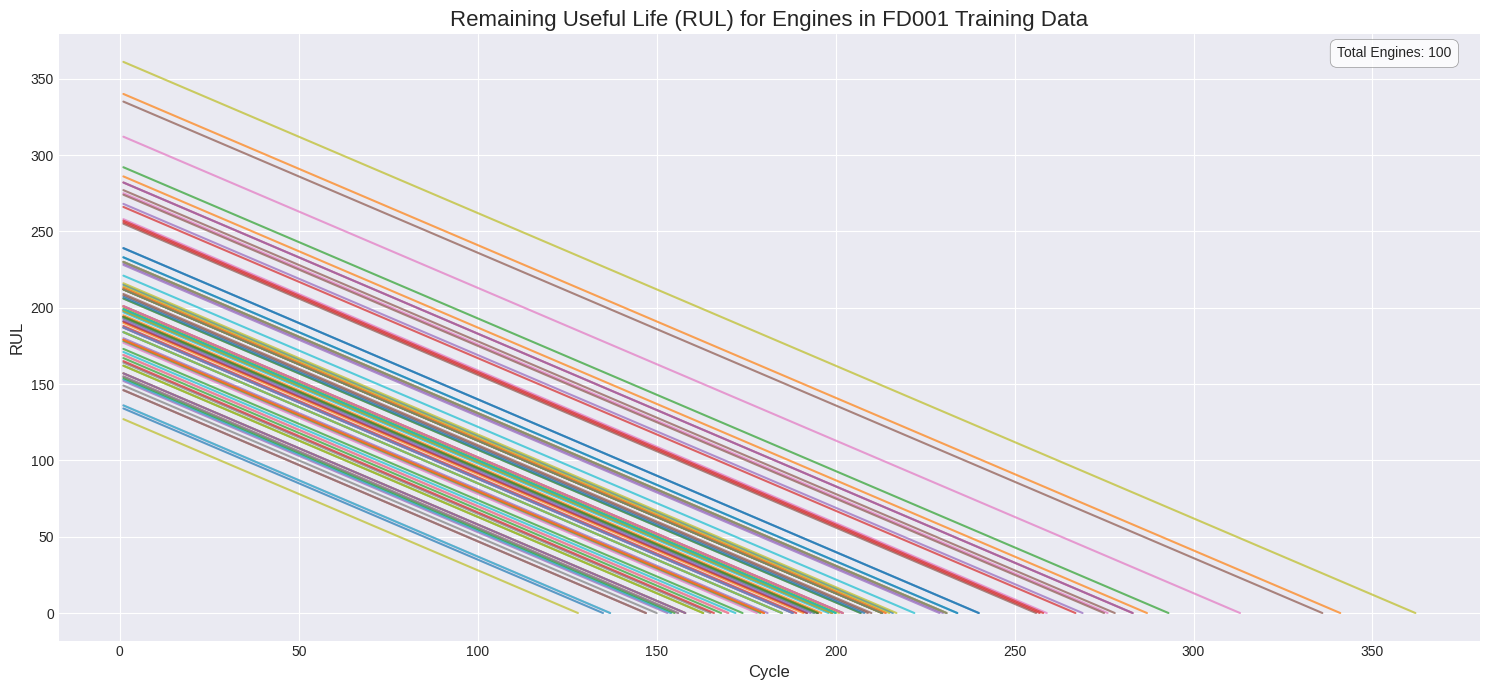

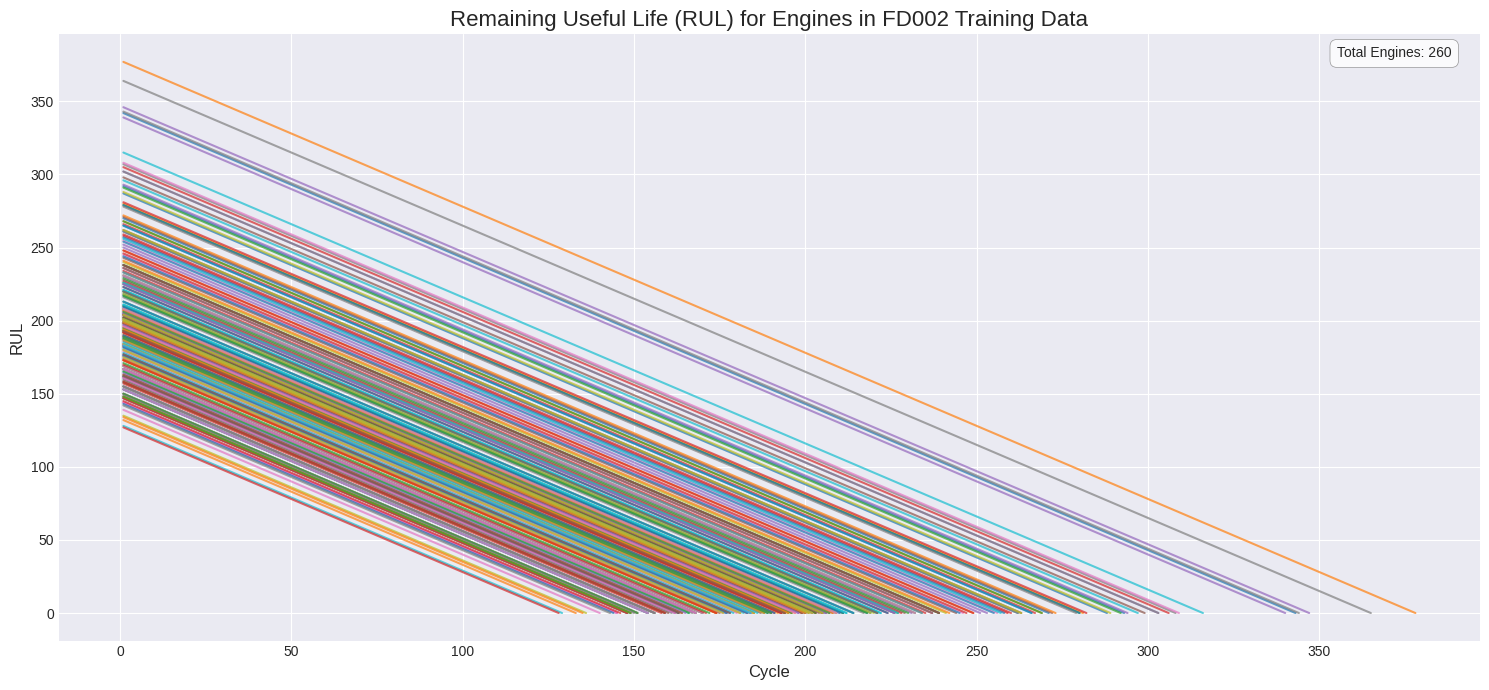

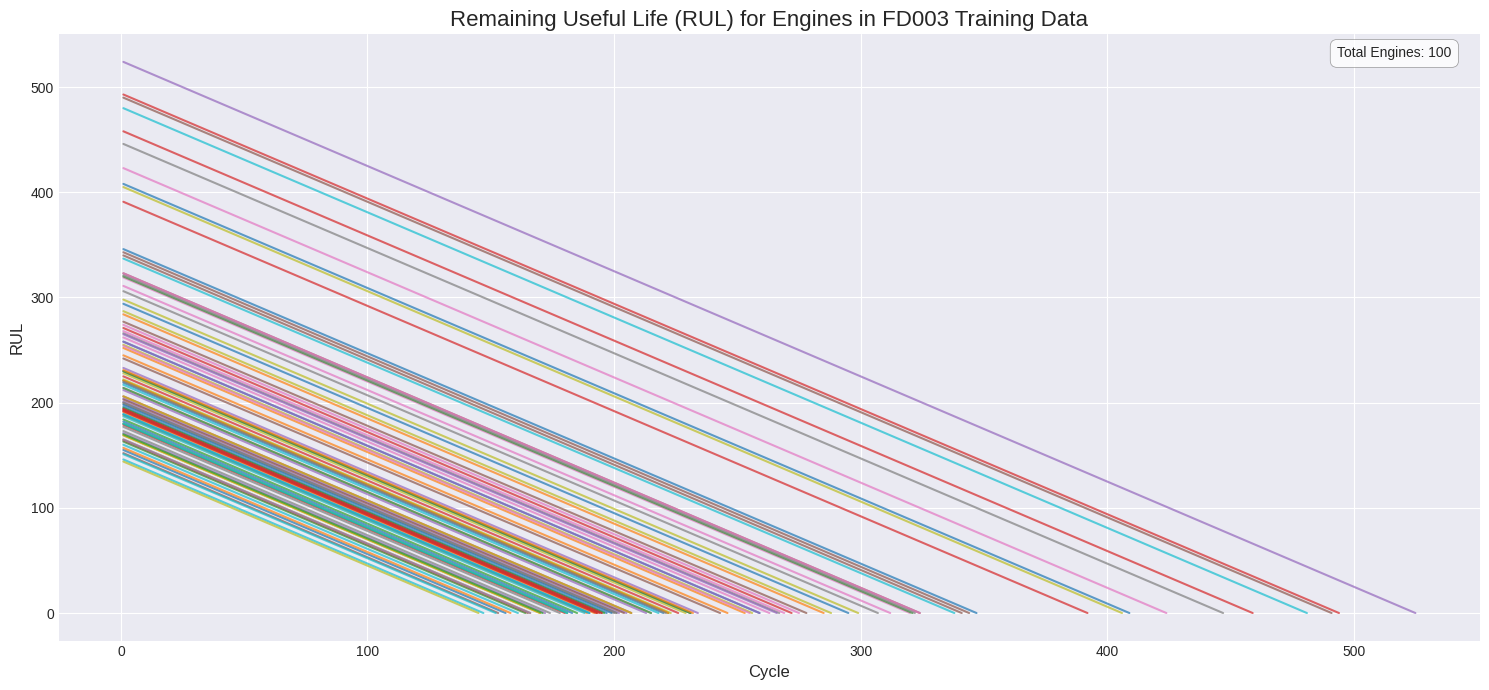

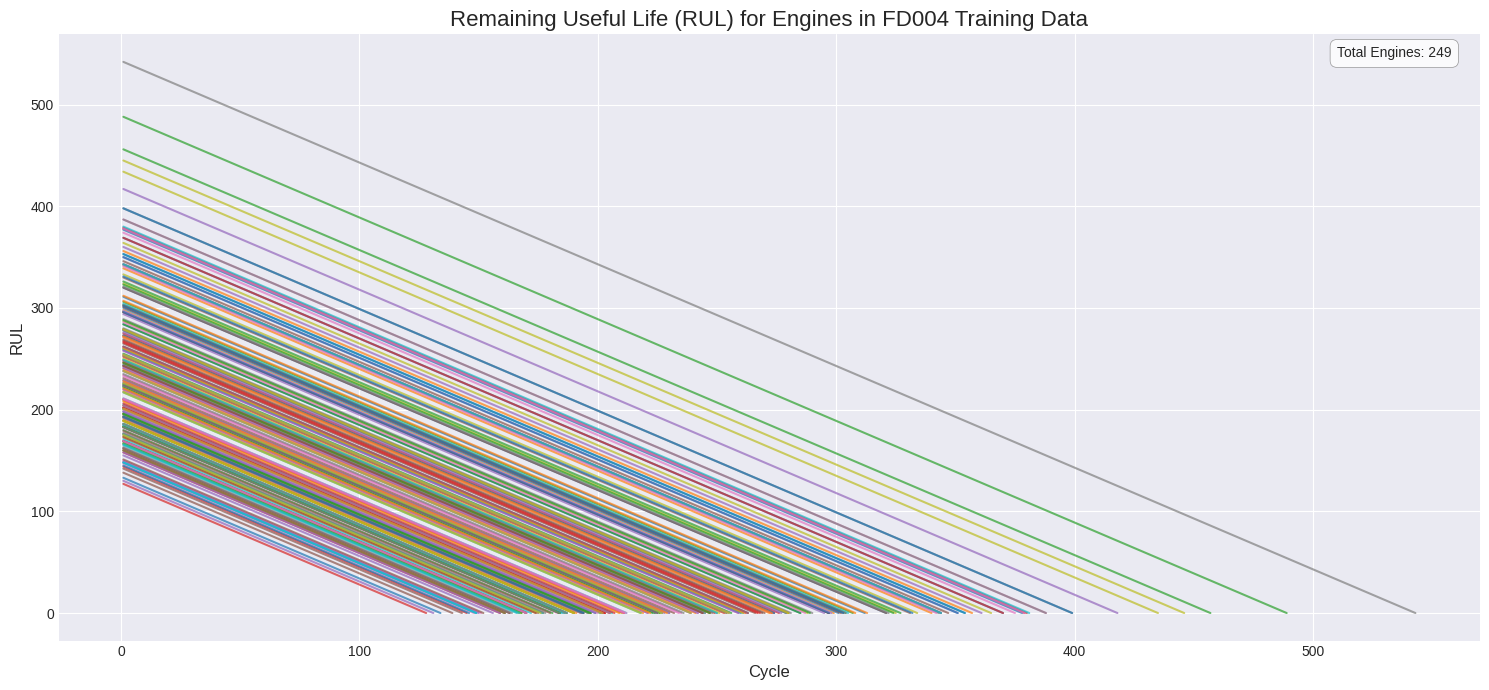

RUL plots generated.


In [20]:
print("Generating RUL plots...")

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')

# Plot RUL for each dataset
for ds_name, df_rul in rul_data_per_dataset.items():
    plt.figure(figsize=(15, 7))

    # Get a list of unique engine IDs in this dataset
    unique_engine_ids = df_rul['id'].unique()

    # Plot RUL for each engine
    for engine_id in unique_engine_ids:
        engine_data = df_rul[df_rul['id'] == engine_id]
        plt.plot(engine_data['cycle'], engine_data['RUL'], alpha=0.7) # Plot without individual labels for clarity due to many lines

    plt.title(f'Remaining Useful Life (RUL) for Engines in {ds_name} Training Data', fontsize=16)
    plt.xlabel('Cycle', fontsize=12)
    plt.ylabel('RUL', fontsize=12)

    # Add a text box indicating the total number of engines for context
    plt.text(0.98, 0.98, f'Total Engines: {len(unique_engine_ids)}',
             transform=plt.gca().transAxes, ha='right', va='top', fontsize=10,
             bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='grey', lw=0.5, alpha=0.8))

    plt.tight_layout()
    plt.show()

print("RUL plots generated.")

These plots illustrate the degradation paths of individual engines across different operational conditions (datasets). As expected, the RUL for each engine generally decreases as the operational cycles increase. This visual representation is crucial for understanding the data's time-to-failure characteristics and for developing predictive maintenance models.